**Trading Algorithm Script:** 

This script builds on Version 2, delving into other trading strategies, such as using Bollinger Bands for a portfolio of the top 10 defence stocks. Once again, I backtest the different strategies and evaluate them using metrics like Maximum Drawdown.  


****************************************************************************************************
****************************************************************************************************
*DISCLAIMER:* AI tools such as Claude and ChatGPT were used to fix coding errors, and suggest improvements to optimise the efficiency of the script. 
****************************************************************************************************
****************************************************************************************************


 

In [ ]:
# Installing the necessary packages:

%pip install pandas 
%pip install requests 
%pip install datetime 
%pip install pandas_datareader 
%pip install matplotlib 
%pip install yfinance  
%pip install copy

In [2]:
import pandas_datareader as pdr 
import datetime
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf 
import copy 

**Importing/Cleaning Data:**


In [3]:
all_data = yf.download(['RTX', 'EADSY', 'RYCEY', 'MTUAY', 'SAFRY', 'RNMBY', 'BAESY', 'SAABY', 'THLLY'], start = "2006-01-01", end = "2026-01-01")
daily_close = all_data["Close"]

[*********************100%***********************]  9 of 9 completed


In [4]:
# Cleaning data: 

daily_close_px_clean = daily_close.dropna(axis=1, thresh=500)
portfolio_price = daily_close_px_clean.mean(axis=1).rename("price")
 

**Creating Bollinger Bands:**

In [5]:
def bollinger_bands(price_series, window=20):
    df = pd.DataFrame({'price': price_series})
    df['std']        = df['price'].rolling(window=window, min_periods=window).std()
    df['mid band']   = df['price'].rolling(window=window, min_periods=window).mean()
    df['upper band'] = df['mid band'] + 2 * df['std']
    df['lower band'] = df['mid band'] - 2 * df['std']
    return df

#  This code returns a DataFrame with price, rolling standard deviation, and mid/upper/lower bands.

*Signal Generation:*

In [7]:
def signal_generation(data, method, window=20, period=75, alpha=0.03, beta=0.02):
    """
    Parameters
    ----------
    data   : pd.Series  — portfolio price
    method : callable   — bollinger_bands()
    window : int        — BB rolling window (default 20)
    period : int        — look-back horizon for W pattern (default 75 ~ 3 months)
    alpha  : float      — tolerance for "close enough" comparisons
                          (scaled as fraction of price, not absolute)
    beta   : float      — contraction threshold for std relative to mid band
    """
    df = method(data, window)
    df['signals']     = 0
    df['cumsum']      = 0
    df['coordinates'] = ''
 
    for i in range(period, len(df)):
        price_i      = df['price'].iloc[i]
        upper_i      = df['upper band'].iloc[i]
        mid_i        = df['mid band'].iloc[i]
        cumsum_i     = df['cumsum'].iloc[i]
        moveon       = False
        threshold    = 0.0
    
        if (price_i > upper_i) and (cumsum_i == 0):
            for j in range(i, i - period, -1):
                price_j = df['price'].iloc[j]
                mid_j   = df['mid band'].iloc[j]
                # tolerance scaled to current mid band level
                tol = alpha * mid_i
                if (abs(mid_j - price_j) < tol) and (abs(mid_j - upper_i) < tol * 10):
                    moveon = True
                    break
 
            if moveon:
                moveon = False
            
                for k in range(j, i - period, -1):
                    price_k = df['price'].iloc[k]
                    lower_k = df['lower band'].iloc[k]
                    tol_k   = alpha * mid_i
                    if abs(lower_k - price_k) < tol_k:
                        threshold = price_k
                        moveon    = True
                        break
 
                if moveon:
                    moveon = False
                    
                    for l in range(k, i - period, -1):
                        if df['mid band'].iloc[l] < df['price'].iloc[l]:
                            moveon = True
                            break
 
                    if moveon:
                        moveon = False
                        
                        for m in range(i, j, -1):
                            price_m = df['price'].iloc[m]
                            lower_m = df['lower band'].iloc[m]
                            tol_m   = alpha * mid_i
                            if (price_m - lower_m < tol_m) and \
                               (price_m > lower_m) and \
                               (price_m < threshold):
                                # All four conditions met → BUY
                                idx = df.index[i]
                                df.at[idx, 'signals']     = 1
                                df.at[idx, 'coordinates'] = '%d,%d,%d,%d,%d' % (l, k, j, m, i)
                                df['cumsum'] = df['signals'].cumsum()
                                moveon = True
                                break
    std_i = df['std'].iloc[i]
    if (cumsum_i != 0) and (std_i / mid_i < beta) and (not moveon):
            idx = df.index[i]
            df.at[idx, 'signals'] = -1
            df['cumsum'] = df['signals'].cumsum()        

    return df             
 

**Running the Strategy:**

In [8]:
signals_df = signal_generation(portfolio_price, bollinger_bands)
 
n_buys  = (signals_df['signals'] ==  1).sum()
n_sells = (signals_df['signals'] == -1).sum()
print(f"  Buy signals:  {n_buys}")
print(f"  Sell signals: {n_sells}\n")

  Buy signals:  1
  Sell signals: 1



**Backtesting the Strategy:**

In [9]:
returns = daily_close_px_clean.pct_change()
portfolio_returns = returns.mean(axis=1)   # equal-weight daily return
 
# Gate returns by the current holding position (0 = cash, 1 = invested)
position = signals_df['cumsum'].clip(0, 1).reindex(portfolio_returns.index).ffill().fillna(0)
strategy_returns  = portfolio_returns * position
benchmark_returns = portfolio_returns   # always invested
 
strategy_cum  = (1 + strategy_returns).cumprod()
benchmark_cum = (1 + benchmark_returns).cumprod()

**Performance Metrics:**

In [10]:
total_strat     = strategy_cum.iloc[-1]  - 1
total_bench     = benchmark_cum.iloc[-1] - 1
sharpe_strat    = np.sqrt(252) * strategy_returns.mean() / strategy_returns.std()
sharpe_bench    = np.sqrt(252) * benchmark_returns.mean() / benchmark_returns.std()
 
print("=" * 45)
print(f"  Strategy total return : {total_strat*100:+.1f}%")
print(f"  Benchmark total return: {total_bench*100:+.1f}%")
print(f"  Strategy Sharpe       : {sharpe_strat:.2f}")
print(f"  Benchmark Sharpe      : {sharpe_bench:.2f}")
print("=" * 45)

  Strategy total return : +409.1%
  Benchmark total return: +2677.5%
  Strategy Sharpe       : 0.69
  Benchmark Sharpe      : 0.76


**Plots:**

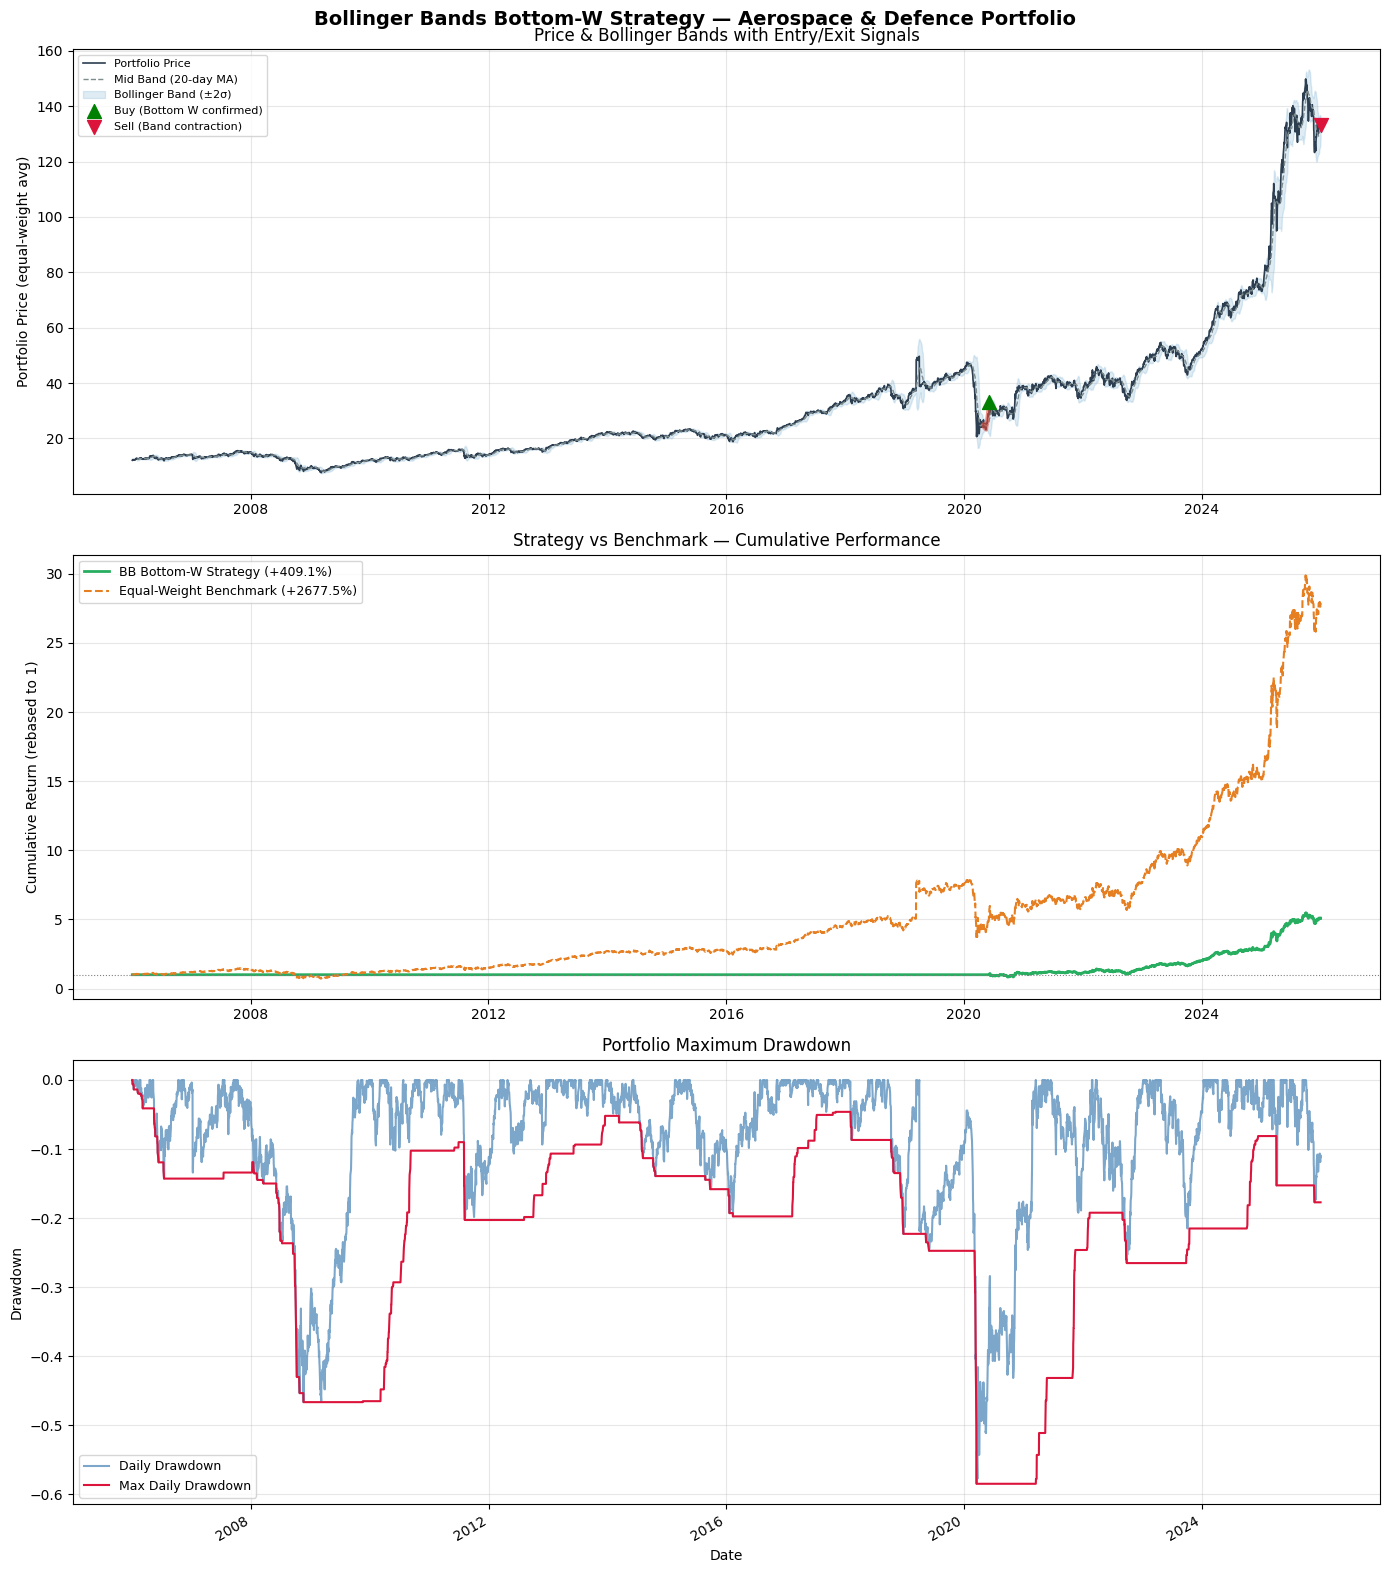

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 16))
fig.suptitle("Bollinger Bands Bottom-W Strategy — Aerospace & Defence Portfolio",
             fontsize=14, fontweight='bold')
 
# Plot 1: Portfolio price with Bollinger Bands and signals ---
ax1 = axes[0]
ax1.plot(signals_df['price'],     color='#2c3e50', lw=1.2, label='Portfolio Price')
ax1.plot(signals_df['mid band'],  color='#7f8c8d', lw=1,   linestyle='--', label='Mid Band (20-day MA)')
ax1.fill_between(signals_df.index,
                 signals_df['lower band'],
                 signals_df['upper band'],
                 alpha=0.15, color='#2980b9', label='Bollinger Band (±2σ)')
 
# Buy / sell markers
buys  = signals_df[signals_df['signals'] ==  1]
sells = signals_df[signals_df['signals'] == -1]
ax1.scatter(buys.index,  buys['price'],  marker='^', color='green',  s=100, zorder=5, label='Buy (Bottom W confirmed)')
ax1.scatter(sells.index, sells['price'], marker='v', color='crimson', s=100, zorder=5, label='Sell (Band contraction)')
 
ax1.set_ylabel('Portfolio Price (equal-weight avg)')
ax1.set_title('Price & Bollinger Bands with Entry/Exit Signals')
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)
 
for idx, row in buys.iterrows():
    if row['coordinates']:
        try:
            node_indices = list(map(int, row['coordinates'].split(',')))
            node_dates   = signals_df.index[node_indices]
            node_prices  = signals_df['price'].iloc[node_indices]
            ax1.plot(node_dates, node_prices, lw=3, alpha=0.6,
                     color='#e74c3c', label='_nolegend_')
        except Exception:
            pass


# Plot 2: Comparing cumulative returns 

ax2 = axes[1]
ax2.plot(strategy_cum,  color='#27ae60', lw=2,   label=f'BB Bottom-W Strategy ({total_strat*100:+.1f}%)')
ax2.plot(benchmark_cum, color='#e67e22', lw=1.5, linestyle='--', label=f'Equal-Weight Benchmark ({total_bench*100:+.1f}%)')
ax2.axhline(1.0, color='grey', lw=0.8, linestyle=':')
ax2.set_ylabel('Cumulative Return (rebased to 1)')
ax2.set_title('Strategy vs Benchmark — Cumulative Performance')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)


# Plot 3: Maximum Drawdown

window_dd = 252
rolling_max        = portfolio_price.rolling(window_dd, min_periods=1).max()
daily_drawdown     = portfolio_price / rolling_max - 1.0
max_daily_drawdown = daily_drawdown.rolling(window_dd, min_periods=1).min()
 
ax3 = axes[2]
daily_drawdown.plot(ax=ax3,     label='Daily Drawdown',     color='steelblue', alpha=0.7)
max_daily_drawdown.plot(ax=ax3, label='Max Daily Drawdown', color='crimson',   lw=1.5)
ax3.set_ylabel('Drawdown')
ax3.set_title('Portfolio Maximum Drawdown')
ax3.legend(loc='lower left', fontsize=9)
ax3.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('bollinger_bands_strategy.png', dpi=150, bbox_inches='tight')
plt.show()

         